# Function 4 Analysis - Week 11

1. **Function description (unchanged):**  
Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

2. **Week 10 evaluated point:** `(0.443936, 0.354755, 0.401800, 0.415518)` returned **≈0.3216**, which is now the **third-best** result so far.

3. **Analysis of top-region structure:** The latest ranking gives a clearer directional pattern: for `x1` and `x2`, the best region appears to lie **between** the second- and third-best values, while for `x3` and `x4` the best-performing area appears to be **below** the incumbent best-point values.

4. **Why we chose last week’s point (from Week 10 logic):** Week 10 treated the poor Week 8 evaluation as a likely logging mismatch and therefore kept an exploitation-biased local GP step near the incumbent basin rather than trusting that outlier.

5. **Recommendation for Week 12 (and how to steer BO):** Keep local GP-based exploitation, but use anisotropic steering constraints: (i) restrict `x1`/`x2` search to the interval bracketed by second- and third-best points, (ii) bias `x3`/`x4` proposals slightly downward relative to the incumbent best, and (iii) keep small step sizes so we refine this local manifold rather than jumping to a different basin.


## Loading and Displaying the Data

We load the inputs and outputs for function 4. Week 10 `(0.443936, 0.354755, 0.401800, 0.415518)` returned **≈0.3216** and has been added to the dataset.


In [30]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_4")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.100000, 0.400000, 0.400000, 0.050000]])
y_new_point_week_1 = np.array([-11.551402216263181])
X_new_point_week_2 = np.array([[0.412000, 0.448200, 0.386300, 0.439500]])
y_new_point_week_2 = np.array([-0.05797573871593498])
X_new_point_week_3 = np.array([[0.426200, 0.452700, 0.391900, 0.429300]])
y_new_point_week_3 = np.array([-0.013999616551390925])
X_new_point_week_4 = np.array([[0.430000, 0.455200, 0.393800, 0.427600]])
y_new_point_week_4 = np.array([-0.09998342305973962])
X_new_point_week_5 = np.array([[0.430300, 0.359300, 0.351800, 0.383700]])
y_new_point_week_5 = np.array([0.5518426262369016])
X_new_point_week_6 = np.array([[0.421100, 0.389600, 0.370500, 0.393100]])
y_new_point_week_6 = np.array([0.37109387744135747])
X_new_point_week_7 = np.array([[0.440000, 0.390769, 0.330000, 0.410000]])
y_new_point_week_7 = np.array([-0.05018491923068735])
X_new_point_week_8 = np.array([[0.436923, 0.340000, 0.380000, 0.407241]])
y_new_point_week_8 = np.array([0.26196137938032793])
X_new_point_week_9 = np.array([[0.425755, 0.309300, 0.301800, 0.433700]])
y_new_point_week_9 = np.array([-1.36678705398441])
X_new_point_week_10 = np.array([[0.443936, 0.354755, 0.401800, 0.415518]])
y_new_point_week_10 = np.array([0.3215923310779307])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

# Display original and y-sorted DataFrames side by side
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.430300,0.359300,0.351800,0.383700,0.551843,0.381275
1,0.421100,0.389600,0.370500,0.393100,0.371094,0.393575
2,0.443936,0.354755,0.401800,0.415518,0.321592,0.404002
3,0.436923,0.340000,0.380000,0.407241,0.261961,0.391041
4,0.426200,0.452700,0.391900,0.429300,-0.014000,0.425025
5,0.440000,0.390769,0.330000,0.410000,-0.050185,0.392692
6,0.412000,0.448200,0.386300,0.439500,-0.057976,0.421500
7,0.430000,0.455200,0.393800,0.427600,-0.099983,0.426650
8,0.425755,0.309300,0.301800,0.433700,-1.366787,0.367639
9,0.577766,0.428772,0.425826,0.249007,-4.025542,0.420343


## Weekly Optimization Progress Summary

Overview of all 10 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 10 update:** `(0.443936, 0.354755, 0.401800, 0.415518)` → **≈0.3216** (not a new maximum).


In [31]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 110)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.100000,0.400000,0.4000,0.050000,-11.551402,-11.551402,✓ NEW MAX,+1.000000
1,2,0.412000,0.448200,0.3863,0.439500,-0.057976,-0.057976,✓ NEW MAX,+11.493426
2,3,0.426200,0.452700,0.3919,0.429300,-0.014000,-0.014000,✓ NEW MAX,+0.043976
3,4,0.430000,0.455200,0.3938,0.427600,-0.099983,-0.014000,✗,-
4,5,0.430300,0.359300,0.3518,0.383700,0.551843,0.551843,✓ NEW MAX,+0.565842
5,6,0.421100,0.389600,0.3705,0.393100,0.371094,0.551843,✗,-
6,7,0.440000,0.390769,0.3300,0.410000,-0.050185,0.551843,✗,-
7,8,0.436923,0.340000,0.3800,0.407241,0.261961,0.551843,✗,-
8,9,0.425755,0.309300,0.3018,0.433700,-1.366787,0.551843,✗,-



📊 Summary: 4/9 weeks achieved new max (Weeks [1, 2, 3, 5])
   Success rate: 44.4% | Final best: 0.551843


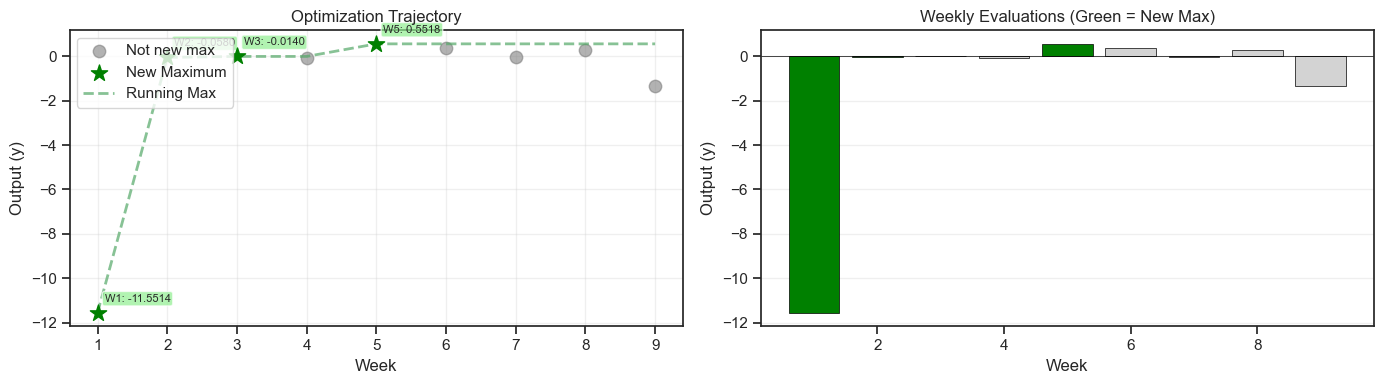

In [32]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Thompson Sampling for Noisy Multi-Modal Landscape

The function is described as "full of local optima" and noisy. Thompson Sampling handles this by:
1. Fitting a GP with explicit noise modeling
2. Drawing random samples from the posterior (not just using the mean)
3. Picking points that look promising across multiple samples

This naturally balances exploration and exploitation without getting trapped.


In [33]:
# Thompson Sampling for noisy, multi-modal optimization
# ======================================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Current best point and top-3 structure
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_x1, best_x2, best_x3, best_x4 = best_point['x1'], best_point['x2'], best_point['x3'], best_point['x4']
best_y = best_point['y']

top3 = df.nlargest(3, 'y').reset_index(drop=True)
second_best = top3.iloc[1]
third_best = top3.iloc[2]

print(f"Current best: ({best_x1:.4f}, {best_x2:.4f}, {best_x3:.4f}, {best_x4:.4f}) = {best_y:.4f}")
print(f"Second best: ({second_best.x1:.4f}, {second_best.x2:.4f}, {second_best.x3:.4f}, {second_best.x4:.4f}) = {second_best.y:.4f}")
print(f"Third best:  ({third_best.x1:.4f}, {third_best.x2:.4f}, {third_best.x3:.4f}, {third_best.x4:.4f}) = {third_best.y:.4f}\n")

# Anisotropic steering based on observed pattern
# - x1/x2: search between 2nd and 3rd best (with a tiny margin)
# - x3/x4: bias downward by capping upper bound at incumbent best values
search_radius = 0.08
bracket_margin = 0.02

x1_low, x1_high = sorted([second_best.x1, third_best.x1])
x2_low, x2_high = sorted([second_best.x2, third_best.x2])

sr_x1_min, sr_x1_max = max(0, x1_low - bracket_margin), min(1, x1_high + bracket_margin)
sr_x2_min, sr_x2_max = max(0, x2_low - bracket_margin), min(1, x2_high + bracket_margin)
sr_x3_min, sr_x3_max = max(0, best_x3 - search_radius), best_x3
sr_x4_min, sr_x4_max = max(0, best_x4 - search_radius), best_x4

print('Anisotropic constrained search region:')
print(f"  x1 ∈ [{sr_x1_min:.3f}, {sr_x1_max:.3f}] (between 2nd/3rd best)")
print(f"  x2 ∈ [{sr_x2_min:.3f}, {sr_x2_max:.3f}] (between 2nd/3rd best)")
print(f"  x3 ∈ [{sr_x3_min:.3f}, {sr_x3_max:.3f}] (capped at incumbent best)")
print(f"  x4 ∈ [{sr_x4_min:.3f}, {sr_x4_max:.3f}] (capped at incumbent best)\n")
# Fit GP with higher noise tolerance (function is noisy!)
kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], length_scale_bounds=(0.01, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))  # High noise!
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}\n")

# Generate candidate grid within search region
grid_res = 12  # 12^4 = 20,736 candidates
grid_x1 = np.linspace(sr_x1_min, sr_x1_max, grid_res)
grid_x2 = np.linspace(sr_x2_min, sr_x2_max, grid_res)
grid_x3 = np.linspace(sr_x3_min, sr_x3_max, grid_res)
grid_x4 = np.linspace(sr_x4_min, sr_x4_max, grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4)).reshape(4, -1).T

print(f"Evaluating {len(mesh)} candidates...")

# Get GP predictions (mean and std)
mu, sigma = gp.predict(mesh, return_std=True)

# Thompson Sampling: draw multiple posterior samples, count wins
n_samples = 500
np.random.seed(42)
win_counts = np.zeros(len(mesh))

for _ in range(n_samples):
    # Sample from posterior: y_sample ~ N(mu, sigma^2)
    samples = mu + sigma * np.random.randn(len(mesh))
    winner = np.argmax(samples)
    win_counts[winner] += 1

print(f"Thompson Sampling: drew {n_samples} posterior samples")

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4'])
candidates['mu'] = mu
candidates['sigma'] = sigma
candidates['wins'] = win_counts
candidates['win_rate'] = win_counts / n_samples

# Filter 1: must be at least 0.015 away from any existing observation
min_dist = 0.015
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2)
    candidates = candidates[dist >= min_dist]

# Also keep moves local to incumbent so we refine the same basin
max_step_from_best = 0.11
best_vec = np.array([best_x1, best_x2, best_x3, best_x4])
cand_vec = candidates[['x1', 'x2', 'x3', 'x4']].values
dist_to_best = np.linalg.norm(cand_vec - best_vec, axis=1)
candidates = candidates[dist_to_best <= max_step_from_best].copy()

print(f"Candidates after distance filter (≥{min_dist} from obs): {len(candidates)}")
print(f"Candidates after local-step filter (dist to best ≤ {max_step_from_best}): {len(candidates)}")

# Filter 2: GP mean must be reasonable (not too far below best)
# Without this, Thompson Sampling picks high-uncertainty edges with terrible expected values
mu_threshold = best_y - 0.5  # Don't consider candidates with mu more than 0.5 below best
candidates_filtered = candidates[candidates['mu'] >= mu_threshold].copy()
print(f"Candidates after GP mean filter (μ ≥ {mu_threshold:.2f}): {len(candidates_filtered)}")

# If no candidates pass the mean filter, fall back to UCB ranking on all candidates
if len(candidates_filtered) < 5:
    print("\nWarning: Few candidates pass mean filter. Using UCB ranking instead.")
    candidates['ucb'] = candidates['mu'] + 0.5 * candidates['sigma']
    selected_pool = candidates.sort_values('ucb', ascending=False).head(300).copy()
    print("\nUsing top UCB pool for range-level aggregation.")
else:
    # Re-run Thompson Sampling on filtered candidates only
    candidates_filtered['wins'] = 0
    mesh_filtered = candidates_filtered[['x1', 'x2', 'x3', 'x4']].values
    mu_filtered = candidates_filtered['mu'].values
    sigma_filtered = candidates_filtered['sigma'].values

    win_counts_filtered = np.zeros(len(candidates_filtered))
    for _ in range(n_samples):
        samples = mu_filtered + sigma_filtered * np.random.randn(len(mu_filtered))
        winner = np.argmax(samples)
        win_counts_filtered[winner] += 1

    candidates_filtered['wins'] = win_counts_filtered
    candidates_filtered['win_rate'] = win_counts_filtered / n_samples
    selected_pool = candidates_filtered.copy()

# Aggregate nearby points into local range categories (neighborhoods)
# This stabilizes decision-making when individual-point wins are diffuse.
group_step = {
    'x1': 2 * (sr_x1_max - sr_x1_min) / (grid_res - 1),
    'x2': 2 * (sr_x2_max - sr_x2_min) / (grid_res - 1),
    'x3': 2 * (sr_x3_max - sr_x3_min) / (grid_res - 1),
    'x4': 2 * (sr_x4_max - sr_x4_min) / (grid_res - 1),
}
starts = {'x1': sr_x1_min, 'x2': sr_x2_min, 'x3': sr_x3_min, 'x4': sr_x4_min}

for dim in ['x1', 'x2', 'x3', 'x4']:
    selected_pool[f'{dim}_grp'] = np.floor((selected_pool[dim] - starts[dim]) / group_step[dim]).astype(int)

group_cols = ['x1_grp', 'x2_grp', 'x3_grp', 'x4_grp']
group_summary = selected_pool.groupby(group_cols).agg(
    wins_sum=('wins', 'sum'),
    points=('wins', 'size'),
    mu_mean=('mu', 'mean'),
    sigma_mean=('sigma', 'mean'),
    x1_min=('x1', 'min'), x1_max=('x1', 'max'),
    x2_min=('x2', 'min'), x2_max=('x2', 'max'),
    x3_min=('x3', 'min'), x3_max=('x3', 'max'),
    x4_min=('x4', 'min'), x4_max=('x4', 'max'),
).reset_index()

group_summary['group_win_rate'] = group_summary['wins_sum'] / n_samples
group_summary = group_summary.sort_values(['wins_sum', 'mu_mean'], ascending=[False, False])

print("\nTop local range groups (aggregated wins):")
display(group_summary.head(10))

# Pick best range group, then pick best point inside that group
if len(group_summary) > 0:
    best_group = group_summary.iloc[0][group_cols].to_dict()
    in_group = selected_pool.copy()
    for c in group_cols:
        in_group = in_group[in_group[c] == best_group[c]]
    top_candidates = in_group.sort_values(['wins', 'mu'], ascending=[False, False]).head(10).copy()
    print("\nTop candidate points inside best range group:")
    display(top_candidates[['x1', 'x2', 'x3', 'x4', 'mu', 'sigma', 'wins', 'win_rate']])
else:
    top_candidates = selected_pool.head(0).copy()

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "=" * 60)
    print("RANGE-AWARE THOMPSON/GP RECOMMENDATION")
    print("=" * 60)
    print(f"Recommended point: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f})")
    print(f"GP prediction: μ={rec['mu']:.4f}, σ={rec['sigma']:.4f}")
    print(f"Point win rate: {rec['win_rate']:.1%} ({int(rec['wins'])}/{n_samples} samples)")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}")
else:
    print("\nNo valid grouped candidates found - try relaxing constraints")


Current best: (0.4303, 0.3593, 0.3518, 0.3837) = 0.5518
Second best: (0.4211, 0.3896, 0.3705, 0.3931) = 0.3711
Third best:  (0.4439, 0.3548, 0.4018, 0.4155) = 0.3216

Anisotropic constrained search region:
  x1 ∈ [0.401, 0.464] (between 2nd/3rd best)
  x2 ∈ [0.335, 0.410] (between 2nd/3rd best)
  x3 ∈ [0.272, 0.352] (capped at incumbent best)
  x4 ∈ [0.304, 0.384] (capped at incumbent best)



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a bette

GP fitted. Kernel: 0.85**2 * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], nu=2.5) + WhiteKernel(noise_level=0.01)

Evaluating 20736 candidates...
Thompson Sampling: drew 500 posterior samples
Candidates after distance filter (≥0.015 from obs): 20122
Candidates after local-step filter (dist to best ≤ 0.11): 20122
Candidates after GP mean filter (μ ≥ 0.05): 354

Top local range groups (aggregated wins):


,x1_grp,x2_grp,x3_grp,x4_grp,wins_sum,points,mu_mean,sigma_mean,x1_min,x1_max,x2_min,x2_max,x3_min,x3_max,x4_min,x4_max,group_win_rate
36,3,5,5,5,50.0,24,0.134169,1.094743,0.435374,0.446799,0.402796,0.409600,0.344527,0.3518,0.376427,0.3837,0.100
10,1,3,5,5,42.0,35,0.116930,1.081558,0.412525,0.423949,0.375580,0.389188,0.344527,0.3518,0.376427,0.3837,0.084
30,3,3,5,5,38.0,35,0.128431,1.068156,0.435374,0.446799,0.375580,0.389188,0.344527,0.3518,0.376427,0.3837,0.076
16,1,5,5,5,35.0,23,0.122395,1.103608,0.412525,0.423949,0.402796,0.409600,0.344527,0.3518,0.376427,0.3837,0.070
2,0,3,5,5,25.0,13,0.088251,1.110022,0.401100,0.406812,0.375580,0.389188,0.344527,0.3518,0.376427,0.3837,0.050
13,1,4,5,5,21.0,12,0.133068,1.092396,0.412525,0.423949,0.395992,0.395992,0.344527,0.3518,0.376427,0.3837,0.042
33,3,4,5,5,19.0,12,0.146582,1.080439,0.435374,0.446799,0.395992,0.395992,0.344527,0.3518,0.376427,0.3837,0.038
39,4,3,5,5,16.0,11,0.102898,1.080381,0.452511,0.452511,0.375580,0.389188,0.344527,0.3518,0.376427,0.3837,0.032
5,0,5,5,5,15.0,9,0.089740,1.126540,0.401100,0.406812,0.402796,0.409600,0.344527,0.3518,0.376427,0.3837,0.030
48,5,5,5,5,15.0,11,0.088659,1.119193,0.458224,0.463936,0.402796,0.409600,0.344527,0.3518,0.376427,0.3837,0.030



Top candidate points inside best range group:


,x1,x2,x3,x4,mu,sigma,wins,win_rate
20302,0.446799,0.409600,0.351800,0.376427,0.126099,1.102562,5.0,0.010
18274,0.435374,0.402796,0.344527,0.376427,0.102458,1.104418,5.0,0.010
18430,0.441087,0.402796,0.351800,0.376427,0.152360,1.087563,4.0,0.008
18574,0.446799,0.402796,0.351800,0.376427,0.140411,1.092301,4.0,0.008
18286,0.435374,0.402796,0.351800,0.376427,0.158198,1.085998,3.0,0.006
18419,0.441087,0.402796,0.344527,0.383700,0.134101,1.088906,3.0,0.006
20003,0.435374,0.409600,0.344527,0.383700,0.125022,1.096940,3.0,0.006
20146,0.441087,0.409600,0.344527,0.376427,0.082230,1.117894,3.0,0.006
18287,0.435374,0.402796,0.351800,0.383700,0.195610,1.067678,2.0,0.004
20303,0.446799,0.409600,0.351800,0.383700,0.164949,1.086404,2.0,0.004



RANGE-AWARE THOMPSON/GP RECOMMENDATION
Recommended point: (0.446799, 0.409600, 0.351800, 0.376427)
GP prediction: μ=0.1261, σ=1.1026
Point win rate: 1.0% (5/500 samples)

Submission format: 0.446799-0.409600-0.351800-0.376427


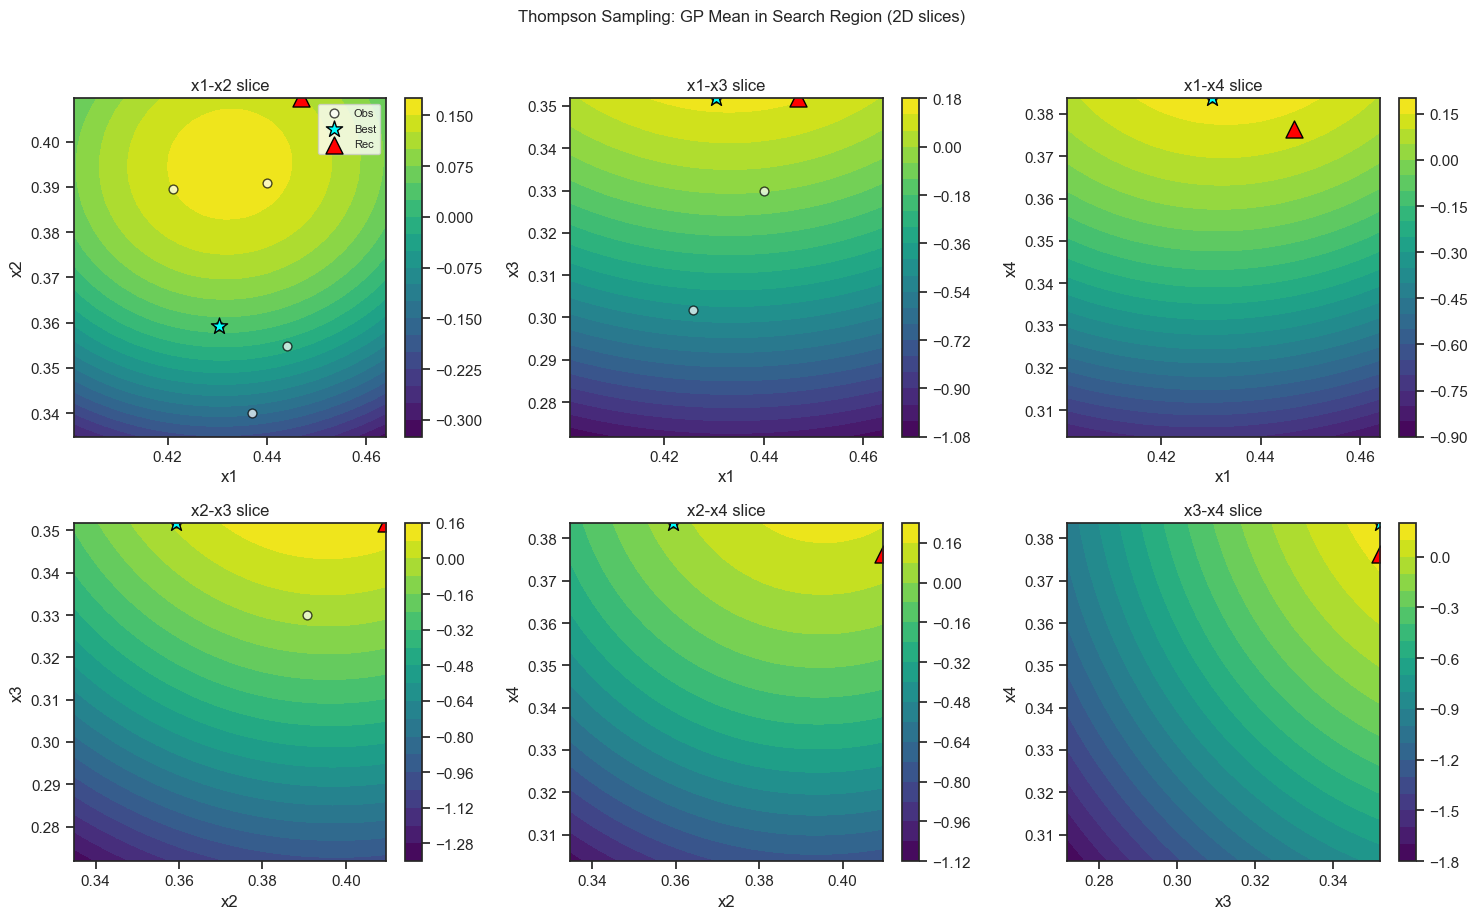

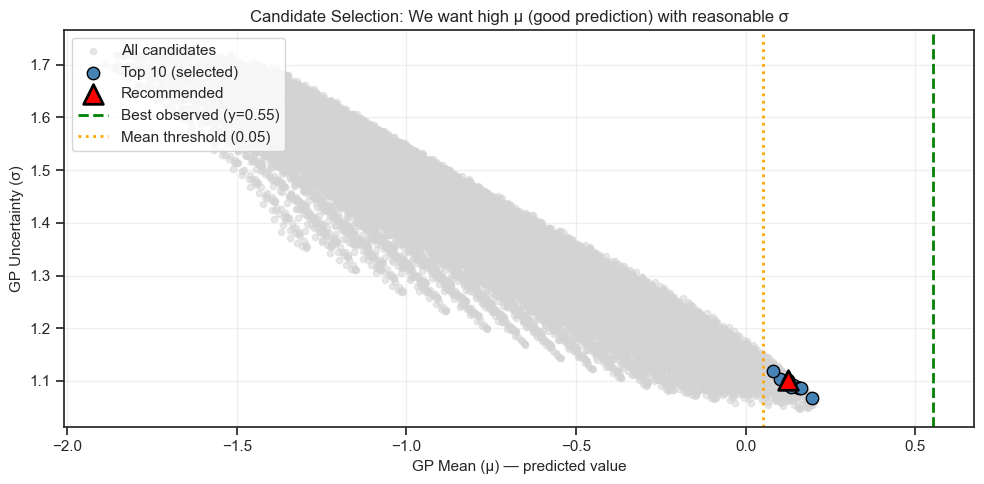

In [34]:
# Visualization: Thompson Sampling results
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    rec_x = {'x1': rec['x1'], 'x2': rec['x2'], 'x3': rec['x3'], 'x4': rec['x4']}
else:
    rec_x = {'x1': best_x1, 'x2': best_x2, 'x3': best_x3, 'x4': best_x4}

# 6 pairwise 2D slices
pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (0, 3, 'x1', 'x4'),
         (1, 2, 'x2', 'x3'), (1, 3, 'x2', 'x4'), (2, 3, 'x3', 'x4')]

sr_bounds = {'x1': (sr_x1_min, sr_x1_max), 'x2': (sr_x2_min, sr_x2_max), 
             'x3': (sr_x3_min, sr_x3_max), 'x4': (sr_x4_min, sr_x4_max)}

for ax_idx, (i, j, label_i, label_j) in enumerate(pairs):
    ax = axes[ax_idx]
    
    # Create 2D grid for this pair
    slice_res = 30
    xi_grid = np.linspace(sr_bounds[label_i][0], sr_bounds[label_i][1], slice_res)
    xj_grid = np.linspace(sr_bounds[label_j][0], sr_bounds[label_j][1], slice_res)
    xxi, xxj = np.meshgrid(xi_grid, xj_grid)
    
    # Build full 4D points for prediction (use column order: x1, x2, x3, x4)
    slice_pts = np.zeros((slice_res * slice_res, 4))
    col_map = {'x1': 0, 'x2': 1, 'x3': 2, 'x4': 3}
    slice_pts[:, col_map[label_i]] = xxi.ravel()
    slice_pts[:, col_map[label_j]] = xxj.ravel()
    for col_name in ['x1', 'x2', 'x3', 'x4']:
        if col_name != label_i and col_name != label_j:
            slice_pts[:, col_map[col_name]] = rec_x[col_name]
    
    slice_mu = gp.predict(slice_pts).reshape(xxi.shape)
    
    im = ax.contourf(xxi, xxj, slice_mu, levels=20, cmap='viridis')
    
    # Plot all observations (use column names directly)
    ax.scatter(df[label_i], df[label_j], c='white', edgecolor='black', s=40, alpha=0.7, label='Obs')
    ax.scatter(best_point[label_i], best_point[label_j], c='cyan', edgecolor='black', s=150, marker='*', label='Best')
    ax.scatter(rec_x[label_i], rec_x[label_j], c='red', edgecolor='black', s=150, marker='^', label='Rec')
    
    # Set axis limits to search region
    ax.set_xlim(sr_bounds[label_i])
    ax.set_ylim(sr_bounds[label_j])
    ax.set_xlabel(label_i)
    ax.set_ylabel(label_j)
    ax.set_title(f'{label_i}-{label_j} slice')
    plt.colorbar(im, ax=ax)

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Thompson Sampling: GP Mean in Search Region (2D slices)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Show GP mean vs uncertainty for candidates (more informative than win rate bar chart)
fig2, ax2 = plt.subplots(figsize=(10, 5))

# Plot all candidates that passed distance filter
ax2.scatter(candidates['mu'], candidates['sigma'], c='lightgray', s=20, alpha=0.5, label='All candidates')

# Highlight top candidates
ax2.scatter(top_candidates['mu'], top_candidates['sigma'], c='steelblue', s=80, edgecolor='black', label='Top 10 (selected)')

# Mark the recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    ax2.scatter(rec['mu'], rec['sigma'], c='red', s=200, marker='^', edgecolor='black', linewidth=2, label='Recommended', zorder=10)

# Mark the best observed y value
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best observed (y={best_y:.2f})')

# Add reference line for mean threshold if it was applied
if 'mu_threshold' in dir():
    ax2.axvline(x=mu_threshold, color='orange', linestyle=':', linewidth=2, label=f'Mean threshold ({mu_threshold:.2f})')

ax2.set_xlabel('GP Mean (μ) — predicted value', fontsize=11)
ax2.set_ylabel('GP Uncertainty (σ)', fontsize=11)
ax2.set_title('Candidate Selection: We want high μ (good prediction) with reasonable σ', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Current best:** `0.430300-0.359300-0.351800-0.383700` (≈0.5518)

**Week 10 evaluated point:** `0.443936-0.354755-0.401800-0.415518` → ≈0.3216 (improved vs prior bad run, and currently third best).

**Proposed next point (submission format):** use the constrained Thompson/GP output printed above.

**How we got to this process (rationale):**
1. We started from point-level Thompson wins, but observed that many candidates had only 1 win, so single-point ranking was unstable.
2. We then added directional steering from the top-result pattern: keep `x1/x2` in the 2nd–3rd-best bracket and bias `x3/x4` below incumbent best.
3. We increased Thompson draws to 500 to reduce Monte Carlo noise in the win estimates.
4. Most importantly, we switched to **range-level aggregation**: nearby candidates are grouped and ranked by combined win mass, then we pick the best point inside the top group.

This makes the recommendation less sensitive to tiny pointwise differences and better aligned with the local structure we have observed in the data.
